In [1]:
# --- Cell 1: Imports ---
import os
import re
import json
from pathlib import Path
from typing import Dict, List, Tuple
import numpy as np
import pandas as pd

In [2]:
# --- Cell 2: Helpers for parsing ---
def parse_number(token: str) -> float:
    """Robust float parser that handles things like '1e15.0' or '1E-3'."""
    try:
        return float(token)
    except ValueError:
        lower = token.lower()
        if 'e' in lower:
            mantissa_str, exp_str = lower.split('e', 1)
            return float(mantissa_str) * (10 ** float(exp_str))
        raise
        
FOLDER_RE = re.compile(
    r"""^
    Zr6_1.0_Zrconc_(?P<Zr>[-+Ee0-9\.]+)
    _FA_(?P<FA>[-+Ee0-9\.]+)
    _L_(?P<L>[-+Ee0-9\.]+)
    _Ratio_(?P<Ratio>[-+Ee0-9\.]+)
    _Step_(?P<Step>[-+Ee0-9\.]+)
    _Index_(?P<Index>\d+)
    _SC_(?P<SC>[-+Ee0-9\.]+)
    _KC_(?P<KC>[-+Ee0-9\.]+)
    _(?P<Date>\d{4}-\d{2}-\d{2})
    _(?P<H>\d{2})_(?P<M>\d{2})_(?P<S>\d{2})
    $""",
    re.X
)

def parse_folder_params(folder_name: str) -> Dict[str, float]:
    m = FOLDER_RE.match(folder_name)
    if not m:
        return {}
    gd = m.groupdict()
    numeric_keys = ["Zr","FA","L","Ratio","Step","Index","SC","KC"]
    out = {k: parse_number(gd[k]) for k in numeric_keys}
    out["Date"] = gd["Date"]
    out["HMS"] = f'{gd["H"]}:{gd["M"]}:{gd["S"]}'
    return out

In [3]:
# --- Cell 3: JSON reader + domain function ---
def read_level_idx_json(json_path: Path) -> List[List[float]]:
    with open(json_path, "r", encoding="utf-8") as f:
        obj = json.load(f)
    if isinstance(obj, dict) and "data" in obj:
        obj = obj["data"]
    clean = []
    for item in obj:
        if isinstance(item, (list, tuple)) and len(item) >= 2:
            clean.append([float(item[0]), float(item[1])])
        elif isinstance(item, dict) and {"t","y"} <= set(item.keys()):
            clean.append([float(item["t"]), float(item["y"])])
    return clean

def effective_equilibrium_constant(KC: np.ndarray,
                                   FA_conc_mM: np.ndarray,
                                   H2O_DMF_RATIO: float = 0.6) -> np.ndarray:
    """
    Calculate effective equilibrium constant given KC and FA concentration in mM.
    Vectorized for numpy arrays.
    """
    # constants
    H2O_pure = 55500   # mM
    DMF_pure = 12900   # mM
    equilibrium_constant = 1.64
    
    # concentrations of solvents
    DMF_conc = DMF_pure / (1 + H2O_DMF_RATIO)
    H2O_conc = H2O_pure * H2O_DMF_RATIO / (1 + H2O_DMF_RATIO)
    
    # coordination power
    H2O_formate_coord_power = H2O_conc / FA_conc_mM * 0.01
    DMF_formate_coord_power = DMF_conc / FA_conc_mM * 0.01
    
    # effective equilibrium constant
    K_eff = KC * equilibrium_constant / (1 + H2O_formate_coord_power + DMF_formate_coord_power)
    return K_eff

In [4]:
# --- Cell 5: Compatibility arrays ---
def build_param_arrays_from(data: Dict[str, List[List[float]]]):
    keys = list(data.keys())
    values = list(data.values())

    param_rows = []
    for key in keys:
        parts = key.split('_')
        chosen = [1, 3, 5, 11, 13]  # Zr, FA, L, SC, KC
        nums = [parse_number(parts[i]) for i in chosen]
        param_rows.append(nums)

    param_result = []
    for value in values:
        arr = np.array(value, dtype=float)
        param_result.append((arr[:, 1] > 0).sum() / len(arr) if arr.size else np.nan)

    param_rows = np.array(param_rows, dtype=float)
    param_result = np.array(param_result, dtype=float)
    param_names = ["Zr", "FA", "L", "SC", "KC"]

    # add K_eff
    Zr, FA, L, SC, KC = [param_rows[:, i] for i in range(param_rows.shape[1])]
    K_eff_all = effective_equilibrium_constant(KC, FA)
    param_rows = np.column_stack([param_rows, K_eff_all])
    param_names += ["K_eff"]

    return param_rows, param_result, param_names

In [5]:
# --- Cell 6: Example run ---
BASE = "./"  # change this

base_dir = BASE
base_dir = Path(base_dir)
rows = []

for json_path in base_dir.rglob("level_idx.json"):
    folder = json_path.parent.name
    params = parse_folder_params(folder)
    if not params:
        continue

    # read dict from JSON
    with open(json_path, "r", encoding="utf-8") as f:
        try:
            data_dict = json.load(f)
        except Exception as e:
            print(f"Skipping {json_path}: {e}")
            continue

    row = {**params, "folder_name": folder, "folder_path": str(json_path.parent)}
    row["growth_data"] = data_dict

    rows.append(row)

In [6]:
entity_number = []
for params in rows:
    data_temp = [temp_["x_value"] for temp_ in params["growth_data"].values()]
    entity_number.append(len(data_temp))

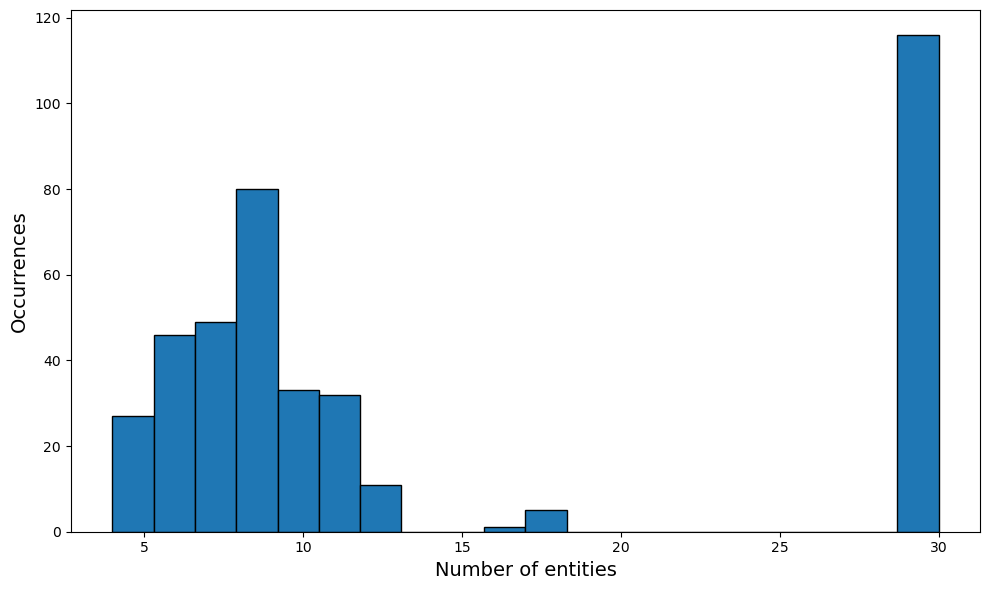

In [7]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.ticker import MultipleLocator

fig, ax = plt.subplots(figsize=(10, 6), facecolor="white")

# Main histogram with edges
ax.hist(entity_number, bins=20, edgecolor="black")
ax.set_xlabel("Number of entities", fontsize=14)
ax.set_ylabel("Occurrences", fontsize=14)

plt.tight_layout()
plt.show()

## Get the speed from 6 to reach thresold

In [8]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_squared_error

thresold = 29

# ---- Build dataset ----
records = []
for params in rows:
    Zr = params.get("Zr", np.nan)
    FA = params.get("FA", np.nan)
    L = params.get("L", np.nan)
    SC = params.get("SC", np.nan)
    KC = params.get("KC", np.nan)
    Index = params.get("Index", np.nan)

    data_temp = [temp_["x_value"] for temp_ in params["growth_data"].values()]
    if len(data_temp) > thresold:
        y_val = np.log(data_temp[thresold] - data_temp[5])
        records.append([Zr, FA, L, SC, KC, Index, y_val])

df = pd.DataFrame(records, columns=["Zr", "FA", "L", "SC", "KC", "Index", "y"])

X = df[["Zr", "FA", "L", "SC", "KC", "Index"]].values
y = df["y"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Arial"
name_map = {
    "SC": "Entropy",
    "KC": "K",
    "K_eff": r"$K_{\mathrm{eff}}$",
    "FA": "Acetic Acid",
    "Zr": r"$c_{\mathrm{Zr}}$",
    "L": r"$c_{\mathrm{ligand}}$",
}

# Prepare
features = ["Zr", "FA", "L", "SC", "KC"]
X_df = df[features].copy()
y = df["y"].values

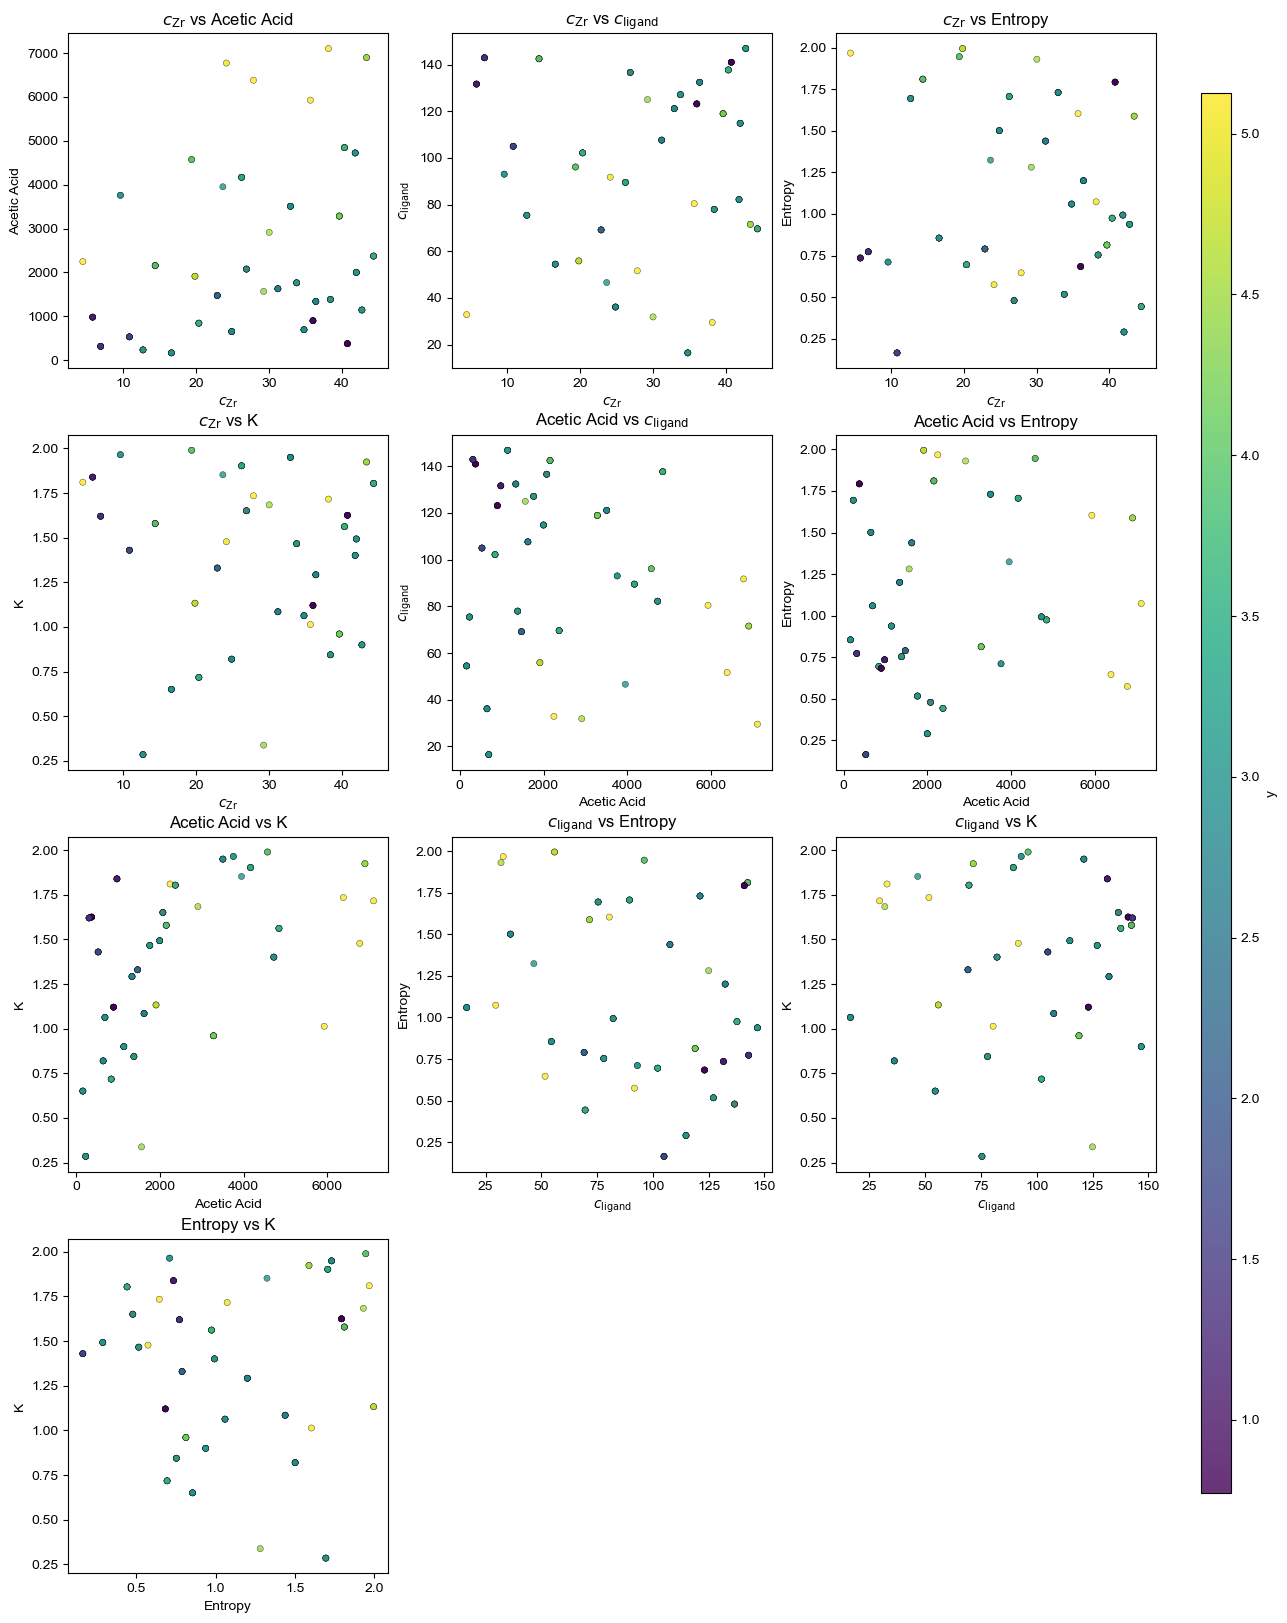

In [10]:
import itertools
import matplotlib.pyplot as plt
import numpy as np

# All unique pairs of features
pairs = list(itertools.combinations(features, 2))

n = len(pairs)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 5*nrows), facecolor="white")
axes = axes.ravel()

# Shared color scale
vmin = np.nanpercentile(y, 2)
vmax = np.nanpercentile(y, 98)

for ax, (f1, f2) in zip(axes, pairs):
    mask = ~X_df[[f1, f2]].isna().any(axis=1) & ~np.isnan(y)
    sc = ax.scatter(
        X_df.loc[mask, f1], X_df.loc[mask, f2],
        c=y[mask], cmap="viridis",
        vmin=vmin, vmax=vmax,
        s=20, alpha=0.8,
        edgecolor="black", linewidth=0.3
    )
    ax.set_xlabel(name_map.get(f1, f1))
    ax.set_ylabel(name_map.get(f2, f2))
    ax.set_title(f"{name_map.get(f1, f1)} vs {name_map.get(f2, f2)}")

# Hide unused axes
for ax in axes[len(pairs):]:
    ax.set_visible(False)

# Adjust subplot area to leave room for colorbar
fig.subplots_adjust(right=0.85)

# Create a new axis for the colorbar outside the plots
cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(sc, cax=cbar_ax)
cbar.set_label("y")

plt.show()

                 Feature  Correlation (r)       p-value
0            Acetic Acid         0.608881  4.124337e-13
1  $c_{\mathrm{ligand}}$        -0.312354  6.412161e-04
2                Entropy         0.239082  9.746132e-03
3      $c_{\mathrm{Zr}}$         0.201040  3.046743e-02
4                      K        -0.022095  8.138806e-01
5                  Index        -0.000158  9.986546e-01


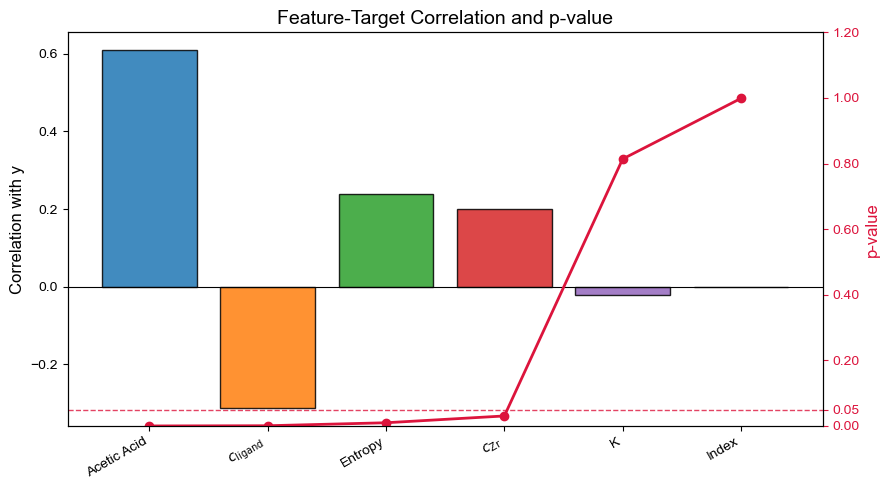

In [11]:
from scipy.stats import pearsonr
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Arial"
name_map = {
    "SC": "Entropy",
    "KC": "K",
    "K_eff": r"$K_{\mathrm{eff}}$",
    "FA": "Acetic Acid",
    "Zr": r"$c_{\mathrm{Zr}}$",
    "L": r"$c_{\mathrm{ligand}}$",
}

features = ["Zr", "FA", "L", "SC", "KC", "Index"]

results = []
for feat in features:
    x = df[feat].values
    y = df["y"].values
    mask = ~pd.isna(x) & ~pd.isna(y)
    r, p = pearsonr(x[mask], y[mask])
    results.append((feat, r, p))

corr_df = pd.DataFrame(results, columns=["Feature", "Correlation (r)", "p-value"])
corr_df["Importance"] = corr_df["Correlation (r)"].abs()
corr_df = corr_df.sort_values("Importance", ascending=False).drop(columns="Importance").reset_index(drop=True)
corr_df["Feature"] = corr_df["Feature"].map(lambda x: name_map.get(x, x))
print(corr_df)

x = list(range(len(corr_df)))
fig, ax1 = plt.subplots(figsize=(9, 5), facecolor="white")

ax1.bar(
    x,
    corr_df["Correlation (r)"],
    color=plt.cm.tab10.colors[:len(corr_df)],
    edgecolor="black",
    alpha=0.85,
)
ax1.axhline(0, color="black", linewidth=0.8)
ax1.set_ylabel("Correlation with y", fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(corr_df["Feature"], rotation=30, ha="right")

ax2 = ax1.twinx()
ax2.plot(x, corr_df["p-value"], color="crimson", marker="o", linewidth=2)
ax2.axhline(0.05, color="crimson", linestyle="--", linewidth=1, alpha=0.8)
ax2.set_ylabel("p-value", color="crimson", fontsize=12)
ax2.tick_params(axis="y", colors="crimson")
p_max = corr_df["p-value"].max()
ax2.set_ylim(0, max(0.06, p_max * 1.1 if pd.notna(p_max) else 0.06))
ticks = sorted(set([tick for tick in ax2.get_yticks() if tick >= 0] + [0.05]))
ax2.set_yticks(ticks)

ax1.set_title("Feature-Target Correlation and p-value", fontsize=14)
fig.tight_layout()
plt.show()

### Nucleation

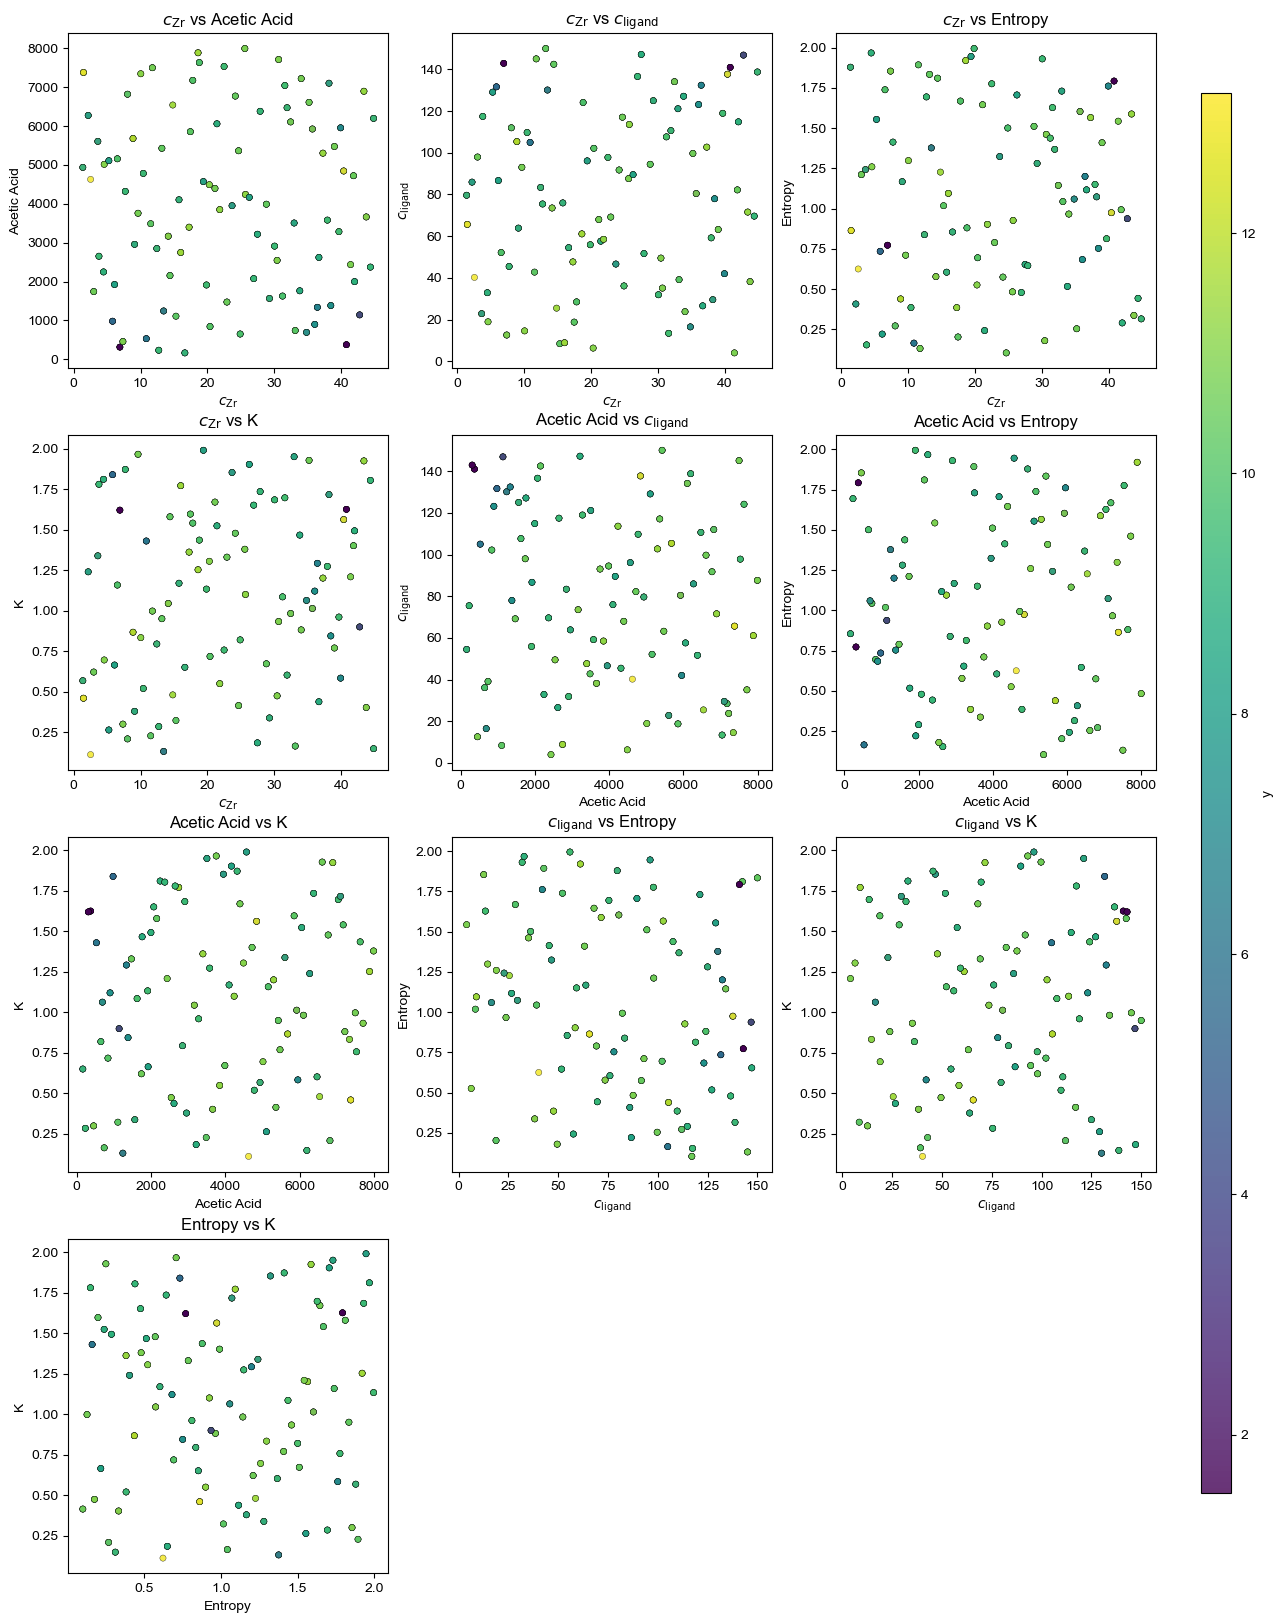

                 Feature  Correlation (r)       p-value
0            Acetic Acid         0.410410  1.376569e-16
1  $c_{\mathrm{ligand}}$        -0.298693  3.999421e-09
2                      K        -0.131851  1.080143e-02
3                Entropy         0.053184  3.056316e-01
4      $c_{\mathrm{Zr}}$        -0.046688  3.685681e-01
5                  Index        -0.021160  6.837605e-01


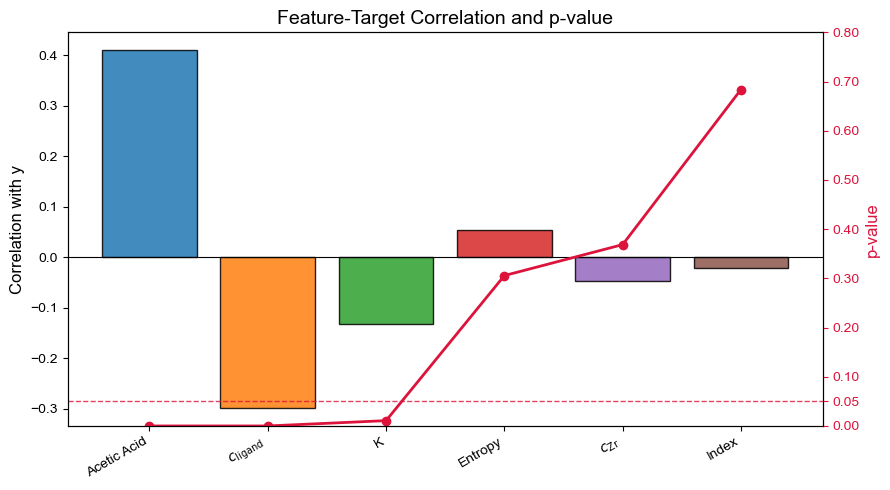

In [12]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_squared_error

thresold = 5
# ---- Build dataset ----
records = []
for params in rows:
    Zr = params.get("Zr", np.nan)
    FA = params.get("FA", np.nan)
    L = params.get("L", np.nan)
    SC = params.get("SC", np.nan)
    KC = params.get("KC", np.nan)
    Index = params.get("Index", np.nan)

    data_temp = [temp_["x_value"] for temp_ in params["growth_data"].values()]
    if len(data_temp) > thresold:
        y_val = np.log(data_temp[5])
        records.append([Zr, FA, L, SC, KC, Index, y_val])

df = pd.DataFrame(records, columns=["Zr", "FA", "L", "SC", "KC", "Index", "y"])

X = df[["Zr", "FA", "L", "SC", "KC", "Index"]].values
y = df["y"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Arial"
name_map = {
    "SC": "Entropy",
    "KC": "K",
    "K_eff": r"$K_{\mathrm{eff}}$",
    "FA": "Acetic Acid",
    "Zr": r"$c_{\mathrm{Zr}}$",
    "L": r"$c_{\mathrm{ligand}}$",
}

# Prepare
features = ["Zr", "FA", "L", "SC", "KC"]
X_df = df[features].copy()
y = df["y"].values

import itertools
import matplotlib.pyplot as plt
import numpy as np

# All unique pairs of features
pairs = list(itertools.combinations(features, 2))

n = len(pairs)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 5*nrows), facecolor="white")
axes = axes.ravel()

# Shared color scale
vmin = np.nanpercentile(y, 2)
vmax = np.nanpercentile(y, 98)

for ax, (f1, f2) in zip(axes, pairs):
    mask = ~X_df[[f1, f2]].isna().any(axis=1) & ~np.isnan(y)
    sc = ax.scatter(
        X_df.loc[mask, f1], X_df.loc[mask, f2],
        c=y[mask], cmap="viridis",
        vmin=vmin, vmax=vmax,
        s=20, alpha=0.8,
        edgecolor="black", linewidth=0.3
    )
    ax.set_xlabel(name_map.get(f1, f1))
    ax.set_ylabel(name_map.get(f2, f2))
    ax.set_title(f"{name_map.get(f1, f1)} vs {name_map.get(f2, f2)}")

# Hide unused axes
for ax in axes[len(pairs):]:
    ax.set_visible(False)

# Adjust subplot area to leave room for colorbar
fig.subplots_adjust(right=0.85)

# Create a new axis for the colorbar outside the plots
cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(sc, cax=cbar_ax)
cbar.set_label("y")

plt.show()

from scipy.stats import pearsonr
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Arial"
features = ["Zr", "FA", "L", "SC", "KC", "Index"]

results = []
for feat in features:
    x = df[feat].values
    y = df["y"].values
    mask = ~pd.isna(x) & ~pd.isna(y)
    r, p = pearsonr(x[mask], y[mask])
    results.append((feat, r, p))

corr_df = pd.DataFrame(results, columns=["Feature", "Correlation (r)", "p-value"])
corr_df["Importance"] = corr_df["Correlation (r)"].abs()
corr_df = corr_df.sort_values("Importance", ascending=False).drop(columns="Importance").reset_index(drop=True)
corr_df["Feature"] = corr_df["Feature"].map(lambda x: name_map.get(x, x))
print(corr_df)

x = list(range(len(corr_df)))
fig, ax1 = plt.subplots(figsize=(9, 5), facecolor="white")

ax1.bar(
    x,
    corr_df["Correlation (r)"],
    color=plt.cm.tab10.colors[:len(corr_df)],
    edgecolor="black",
    alpha=0.85,
)
ax1.axhline(0, color="black", linewidth=0.8)
ax1.set_ylabel("Correlation with y", fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(corr_df["Feature"], rotation=30, ha="right")

ax2 = ax1.twinx()
ax2.plot(x, corr_df["p-value"], color="crimson", marker="o", linewidth=2)
ax2.axhline(0.05, color="crimson", linestyle="--", linewidth=1, alpha=0.8)
ax2.set_ylabel("p-value", color="crimson", fontsize=12)
ax2.tick_params(axis="y", colors="crimson")
p_max = corr_df["p-value"].max()
ax2.set_ylim(0, max(0.06, p_max * 1.1 if pd.notna(p_max) else 0.06))
ticks = sorted(set([tick for tick in ax2.get_yticks() if tick >= 0] + [0.05]))
ax2.set_yticks(ticks)

ax1.set_title("Feature-Target Correlation and p-value", fontsize=14)
fig.tight_layout()
plt.show()

                 Feature  Correlation (r)   p-value
0            Acetic Acid         0.317710  0.000510
1      $c_{\mathrm{Zr}}$         0.112560  0.228975
2                Entropy         0.035288  0.706871
3                      K         0.035079  0.708526
4  $c_{\mathrm{ligand}}$         0.021195  0.821333
5                  Index         0.019702  0.833728


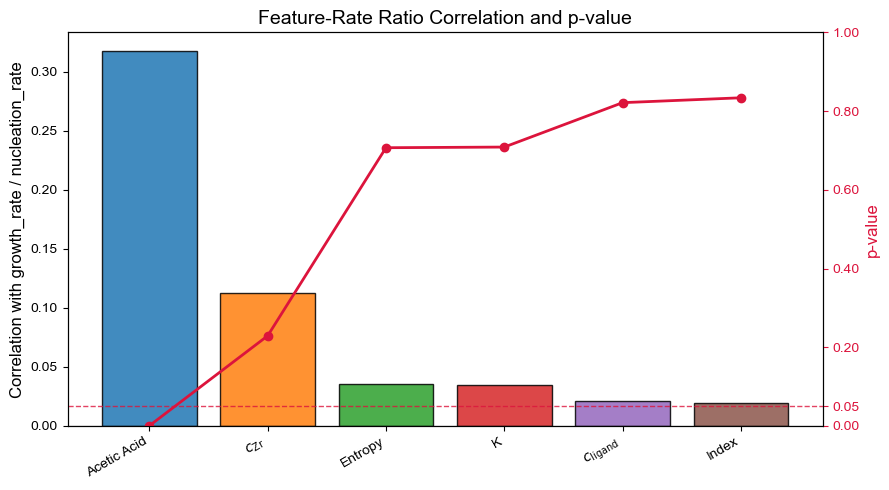

In [13]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Arial"
name_map = {
    "SC": "Entropy",
    "KC": "K",
    "K_eff": r"$K_{\mathrm{eff}}$",
    "FA": "Acetic Acid",
    "Zr": r"$c_{\mathrm{Zr}}$",
    "L": r"$c_{\mathrm{ligand}}$",
}

nucleation_idx = 5
growth_end_idx = 29  # change to 19 if you want the 6 -> 20 window

records = []
for params in rows:
    data_temp = [temp_["x_value"] for temp_ in params["growth_data"].values()]

    if len(data_temp) <= growth_end_idx:
        continue

    nucleation_time = data_temp[nucleation_idx]
    growth_time = data_temp[growth_end_idx] - data_temp[nucleation_idx]

    if nucleation_time <= 0 or growth_time <= 0:
        continue

    nucleation_rate = 1.0 / nucleation_time
    growth_rate = 1.0 / growth_time
    rate_ratio = growth_rate / nucleation_rate

    records.append([
        params.get("Zr", np.nan),
        params.get("FA", np.nan),
        params.get("L", np.nan),
        params.get("SC", np.nan),
        params.get("KC", np.nan),
        params.get("Index", np.nan),
        nucleation_time,
        growth_time,
        nucleation_rate,
        growth_rate,
        rate_ratio,
    ])

ratio_df = pd.DataFrame(
    records,
    columns=[
        "Zr", "FA", "L", "SC", "KC", "Index",
        "nucleation_time", "growth_time",
        "nucleation_rate", "growth_rate", "rate_ratio",
    ],
)

features = ["Zr", "FA", "L", "SC", "KC", "Index"]

results = []
for feat in features:
    x = ratio_df[feat].to_numpy()
    y = ratio_df["rate_ratio"].to_numpy()
    mask = ~pd.isna(x) & ~pd.isna(y)

    if mask.sum() < 2 or np.nanstd(x[mask]) == 0 or np.nanstd(y[mask]) == 0:
        r, p = np.nan, np.nan
    else:
        r, p = pearsonr(x[mask], y[mask])

    results.append((feat, r, p))

corr_ratio_df = pd.DataFrame(results, columns=["Feature", "Correlation (r)", "p-value"])
corr_ratio_df["Importance"] = corr_ratio_df["Correlation (r)"].abs()
corr_ratio_df = corr_ratio_df.sort_values("Importance", ascending=False).drop(columns="Importance").reset_index(drop=True)
corr_ratio_df["Feature"] = corr_ratio_df["Feature"].map(lambda x: name_map.get(x, x))
print(corr_ratio_df)

x = list(range(len(corr_ratio_df)))
fig, ax1 = plt.subplots(figsize=(9, 5), facecolor="white")

ax1.bar(
    x,
    corr_ratio_df["Correlation (r)"],
    color=plt.cm.tab10.colors[:len(corr_ratio_df)],
    edgecolor="black",
    alpha=0.85,
)
ax1.axhline(0, color="black", linewidth=0.8)
ax1.set_ylabel("Correlation with growth_rate / nucleation_rate", fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(corr_ratio_df["Feature"], rotation=30, ha="right")

ax2 = ax1.twinx()
ax2.plot(x, corr_ratio_df["p-value"], color="crimson", marker="o", linewidth=2)
ax2.axhline(0.05, color="crimson", linestyle="--", linewidth=1, alpha=0.8)
ax2.set_ylabel("p-value", color="crimson", fontsize=12)
ax2.tick_params(axis="y", colors="crimson")
p_max = corr_ratio_df["p-value"].max()
ax2.set_ylim(0, max(0.06, p_max * 1.1 if pd.notna(p_max) else 0.06))
ticks = sorted(set([tick for tick in ax2.get_yticks() if tick >= 0] + [0.05]))
ax2.set_yticks(ticks)

ax1.set_title("Feature-Rate Ratio Correlation and p-value", fontsize=14)
fig.tight_layout()
plt.show()
